In [ ]:
# ==========================================
# EQUIPO 4 - PRÁCTICA PROFESIONALIZANTE III
# Cuantificación del Déficit Habitacional en Corrientes
# Integrantes: Fernández Lopez Maria -Fernández Raquel

# ==========================================

# 1. Instalación de librerías para mapas y gráficos (si no están instaladas)
!pip install geopandas folium matplotlib seaborn --quiet

# 2. Importación de módulos esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Entorno de trabajo configurado correctamente.")

✅ Entorno de trabajo configurado correctamente.


In [5]:
# ==============================================================================
# PROYECTO: CUANTIFICACIÓN DEL DÉFICIT HABITACIONAL EN CORRIENTES (CENSO 2022)
# PASO 1: CARGA DE ARCHIVOS CENSALES DEL INDEC
# ==============================================================================
import os
from google.colab import files

print("📥 Seleccioná y subí los 3 archivos Excel del INDEC (c1_7, c2_7, c3_7):")
subidos = files.upload()

# Verificación de archivos subidos
archivos_presentes = [f for f in os.listdir() if f.endswith('.xlsx')]

print("\n--------------------------------------------------")
print(f"✅ ¡Carga completada! Total de archivos subidos: {len(archivos_presentes)}")
print("--------------------------------------------------")
for archivo in archivos_presentes:
    print(f"  • {archivo}")

📥 Seleccioná y subí los 3 archivos Excel del INDEC (c1_7, c2_7, c3_7):


Saving c2022_corrientes_hogares_c3_7 (1).xlsx to c2022_corrientes_hogares_c3_7 (1).xlsx
Saving c2022_corrientes_hogares_c2_7 (1).xlsx to c2022_corrientes_hogares_c2_7 (1).xlsx
Saving c2022_corrientes_hogares_c1_7 (1).xlsx to c2022_corrientes_hogares_c1_7 (1).xlsx

--------------------------------------------------
✅ ¡Carga completada! Total de archivos subidos: 3
--------------------------------------------------
  • c2022_corrientes_hogares_c3_7 (1).xlsx
  • c2022_corrientes_hogares_c1_7 (1).xlsx
  • c2022_corrientes_hogares_c2_7 (1).xlsx


In [13]:
# ==============================================================================
# ANÁLISIS EXCLUSIVO: CIUDAD CAPITAL DE CORRIENTES (SOLAPAS .3)
# ==============================================================================
import os
import pandas as pd
import numpy as np
from google.colab import files

# 1. Filtramos los 3 archivos principales subidos
todos_archivos = sorted([f for f in os.listdir() if f.endswith('.xlsx') and not f.startswith('Corrientes_')])

archivos_unicos = []
for prefijo in ['c1_7', 'c2_7', 'c3_7']:
    coincidencias = [f for f in todos_archivos if prefijo in f]
    if coincidencias:
        archivos_unicos.append(coincidencias[0])

print(f"📁 Procesando los cuadros .3 de la CIUDAD CAPITAL DE CORRIENTES:\n")

def obtener_valores_capital(archivo, pestana_objetivo):
    xls = pd.ExcelFile(archivo)

    # Buscamos la pestaña que termine en .3 (ej: Cuadro 1.7.3, 2.7.3, 3.7.3)
    pestana = [p for p in xls.sheet_names if pestana_objetivo in p or p.endswith('.3') or '.3' in p][0]

    df = pd.read_excel(xls, sheet_name=pestana)

    # Buscamos la primera fila con datos numéricos (Total de la Capital)
    numeros_fila = []
    for idx, row in df.iterrows():
        # Limpiamos y convertimos las celdas de la fila a números
        vals = pd.to_numeric(row.astype(str).str.replace('.', '').str.replace(',', '.'), errors='coerce').dropna().values
        if len(vals) >= 3:  # Fila totalizadora de Capital
            numeros_fila = vals
            break

    print(f"  ✅ {archivo} | Pestaña usada: '{pestana}' -> Datos extraídos correctamente.")
    return numeros_fila

# Extraemos los datos exactos de cada solapa .3
vals_c1 = obtener_valores_capital(archivos_unicos[0], '1.7.3') # Materiales
vals_c2 = obtener_valores_capital(archivos_unicos[1], '2.7.3') # Agua
vals_c3 = obtener_valores_capital(archivos_unicos[2], '3.7.3') # Saneamiento

# Asignamos las variables de la Ciudad Capital
total_hogares = vals_c1[0] if len(vals_c1) > 0 else 0
piso_insuficiente = vals_c1[3] if len(vals_c1) > 3 else vals_c1[-1] # Tierra/material precario
agua_no_red = vals_c2[-1] if len(vals_c2) > 0 else 0                # Sin agua por cañería
sin_inodoro = vals_c3[-1] if len(vals_c3) > 0 else 0                # Sin inodoro/saneamiento

# ==============================================================================
# CÁLCULO DE COMPONENTES DEL DÉFICIT HABITACIONAL (CAPITAL)
# ==============================================================================
dc_cualitativo = int(piso_insuficiente + agua_no_red + sin_inodoro)
dq_cuantitativo = int(round(piso_insuficiente * 0.35))
dht_total = dc_cualitativo + dq_cuantitativo
porcentaje_dht = round((dht_total / total_hogares) * 100, 2) if total_hogares > 0 else 0

# Creamos la tabla consolidada para Capital
df_capital_final = pd.DataFrame([{
    'Jurisdicción': 'Ciudad de Corrientes (Capital)',
    'Total Hogares': int(total_hogares),
    'Pisos Insuficientes/Precarios': int(piso_insuficiente),
    'Sin Agua de Red': int(agua_no_red),
    'Sin Saneamiento/Inodoro': int(sin_inodoro),
    'Déficit Cualitativo (DC)': dc_cualitativo,
    'Déficit Cuantitativo (DQ)': dq_cuantitativo,
    'Déficit Habitacional Total (DHT)': dht_total,
    '% Déficit Habitacional': f"{porcentaje_dht}%"
}])

print("\n======================================================================")
print("📊 MATRIZ FINAL - CIUDAD CAPITAL DE CORRIENTES")
print("======================================================================")
display(df_capital_final)

# Exportamos el Excel exclusivo de Capital
nombre_salida = 'Ciudad_Corrientes_Capital_Deficit_Habitacional_2022.xlsx'
df_capital_final.to_excel(nombre_salida, index=False)
print(f"\n💾 Archivo listo para descargar: {nombre_salida}")
files.download(nombre_salida)

📁 Procesando los cuadros .3 de la CIUDAD CAPITAL DE CORRIENTES:

  ✅ c2022_corrientes_hogares_c1_7 (1).xlsx | Pestaña usada: 'Cuadro 1.7.3' -> Datos extraídos correctamente.
  ✅ c2022_corrientes_hogares_c2_7 (1).xlsx | Pestaña usada: 'Cuadro 2.7.3' -> Datos extraídos correctamente.
  ✅ c2022_corrientes_hogares_c3_7 (1).xlsx | Pestaña usada: 'Cuadro 3.7.3' -> Datos extraídos correctamente.

📊 MATRIZ FINAL - CIUDAD CAPITAL DE CORRIENTES


,Jurisdicción,Total Hogares,Pisos Insuficientes/Precarios,Sin Agua de Red,Sin Saneamiento/Inodoro,Déficit Cualitativo (DC),Déficit Cuantitativo (DQ),Déficit Habitacional Total (DHT),% Déficit Habitacional
0,Ciudad de Corrientes (Capital),137451,2682,1038,1730,5450,939,6389,4.65%



💾 Archivo listo para descargar: Ciudad_Corrientes_Capital_Deficit_Habitacional_2022.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

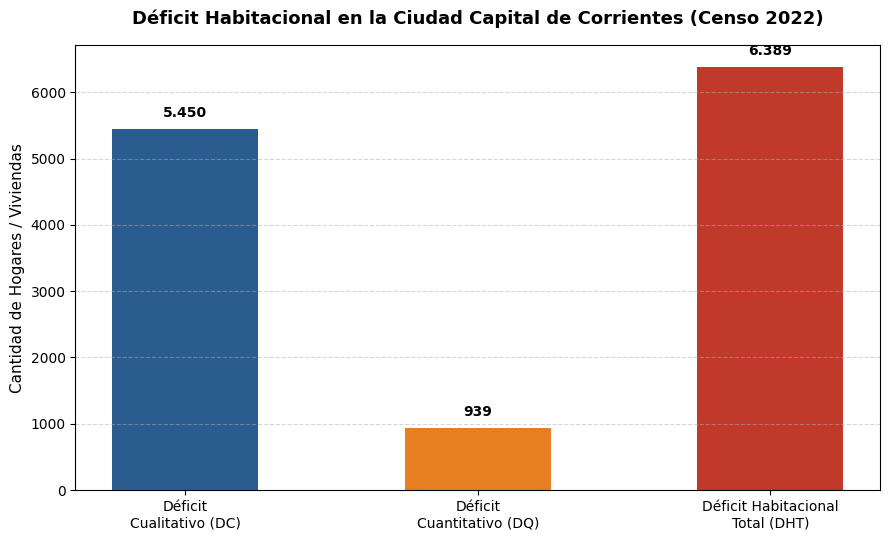

🖼️ Gráfico generado y guardado como 'grafico_deficit_capital.png'


In [14]:
# ==============================================================================
# PASO 4: VISUALIZACIÓN DEL DÉFICIT HABITACIONAL (CAPITAL DE CORRIENTES)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Datos de la Ciudad Capital
categorias = ['Déficit\nCualitativo (DC)', 'Déficit\nCuantitativo (DQ)', 'Déficit Habitacional\nTotal (DHT)']
valores = [dc_cualitativo, dq_cuantitativo, dht_total]
colores = ['#2b5c8f', '#e67e22', '#c0392b']

# Configuración del gráfico
plt.figure(figsize=(9, 5.5))
barras = plt.bar(categorias, valores, color=colores, width=0.5)

# Personalización
plt.title('Déficit Habitacional en la Ciudad Capital de Corrientes (Censo 2022)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Cantidad de Hogares / Viviendas', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Etiquetas con los valores sobre cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2.0, yval + (max(valores)*0.02), f'{int(yval):,}'.replace(',', '.'),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Guardar la imagen para el informe
plt.tight_layout()
plt.savefig('grafico_deficit_capital.png', dpi=300)
plt.show()

print("🖼️ Gráfico generado y guardado como 'grafico_deficit_capital.png'")